# 260413-2: PyTorch로 다층 신경망(MLP) 구현하기

260413-1에서 numpy로 직접 구현했던 forward/backward를 이제는 **PyTorch**가 자동으로 처리해줍니다.
이번 실습에서는 PyTorch의 `nn.Module`과 `nn.Sequential` API를 사용하여 MLP를 구현합니다.

## 학습 목표
- PyTorch **autograd**가 수동 backward를 어떻게 대체하는지 이해하기
- `nn.Module` API로 커스텀 신경망 구현하기
- `nn.Sequential` API로 간결한 모델 정의하기
- PyTorch 학습 루프 (forward → loss → backward → step) 작성하기
- Residual connection이 깊은 네트워크의 gradient 흐름에 미치는 영향을 관찰하기
- `model.train()` / `model.eval()` 모드 차이 이해하기

## 목차
1. [autograd: numpy에서 PyTorch로 바꾸는 이유](#1.-autograd:-numpy에서-PyTorch로-바꾸는-이유)
2. [nn.Module API](#2.-nn.Module-API)
3. [ThreeLayerMLP 구현 (TODO 1)](#3.-ThreeLayerMLP-구현)
4. [학습 및 평가 (TODO 2)](#4.-학습-및-평가)
5. [nn.Sequential API (TODO 3)](#5.-nn.Sequential-API)
6. [Residual Connection (TODO 4)](#6.-Residual-Connection)
7. [train() vs eval() 모드](#7.-train()-vs-eval()-모드)
8. [정리 및 실용 팁](#정리-및-실용-팁)


### Recap: 260413-1 (numpy) vs 260413-2 (PyTorch)

260413-1에서 **직접 구현**했던 것들을 PyTorch가 **자동으로** 처리해줍니다:

| 항목 | 260413-1 (numpy, 수동) | 260413-2 (PyTorch, 자동) |
|------|---------------------|----------------------|
| 선형 변환 | `affine_forward` / `affine_backward` 직접 구현 | `nn.Linear` 한 줄 |
| 활성화 함수 | `relu_forward` / `relu_backward` 직접 구현 | `nn.ReLU()` 또는 `F.relu()` |
| 손실 함수 | `softmax_loss` 직접 구현 (log-sum-exp) | `F.cross_entropy()` 한 줄 |
| 중간값 관리 | `cache`를 직접 저장/전달 | `autograd`가 자동 관리 |
| Gradient 계산 | 체인룰로 수동 역전파 | `loss.backward()` 한 줄 |
| 파라미터 업데이트 | `w -= lr * dw` 수동 연산 | `optimizer.step()` 한 줄 |
| 파라미터 수집 | dict로 직접 관리 | `model.parameters()` 자동 수집 |

> 앞서 numpy로 직접 구현해봤으므로, PyTorch API가 무엇을 대신 처리해주는지 비교하면서 따라가면 됩니다.


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available:')
        print(gpu_info.stdout.split('\n')[8])
    else:
        print('No GPU detected. Go to Runtime > Change runtime type > GPU')

GPU available:
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# ── CIFAR-10 데이터 로딩 ──
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_set, val_set = torch.utils.data.random_split(
    trainset, [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)
test_loader = DataLoader(testset, batch_size=256, shuffle=False)

CLASSES = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(testset)}')

# ── 헬퍼 함수들 ──
@torch.no_grad()
def check_accuracy(loader, model):
    """모델의 정확도를 계산합니다."""
    model.eval()
    num_correct = 0
    num_samples = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        _, preds = scores.max(1)
        num_correct += (preds == y).sum().item()
        num_samples += preds.size(0)
    return num_correct / num_samples


def train_model(model, optimizer, train_loader, val_loader, epochs=5, verbose=True):
    """
    모델을 학습하고 loss/accuracy 히스토리를 반환합니다.
    Returns:
        history: dict with 'train_loss', 'train_acc', 'val_acc'
    """
    model = model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        num_batches = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        avg_loss = running_loss / num_batches
        train_acc = check_accuracy(train_loader, model)
        val_acc = check_accuracy(val_loader, model)

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    return history

Using device: cuda


100%|██████████| 170M/170M [00:06<00:00, 25.0MB/s]


Train: 45000, Val: 5000, Test: 10000


## 1. autograd: numpy에서 PyTorch로 바꾸는 이유

260413-1에서는 각 레이어의 backward를 직접 작성했지만, PyTorch의 **autograd**는 forward 연산을 추적하여 `.backward()` 한 번으로 모든 gradient를 자동 계산합니다.

### 핵심 개념
- `requires_grad=True`: 이 텐서에 대한 gradient를 추적하겠다는 의미
- `loss.backward()`: 역전파를 실행하여 모든 관련 텐서의 `.grad`에 gradient를 저장
- `torch.no_grad()`: gradient 추적을 비활성화 (추론 시 메모리/속도 절약)

아래에서 간단한 $f(x) = x^2$ 예제로 수동 계산과 autograd 결과를 비교합니다.


In [3]:
# === autograd 데모: f(x) = x^2, f'(x) = 2x ===

# 수동 gradient (260413-1 style)
x_val = 3.0
manual_grad = 2 * x_val  # f'(x) = 2x
print(f'=== f(x) = x^2 at x = {x_val} ===')
print(f'Manual gradient: f\'({x_val}) = 2 * {x_val} = {manual_grad}')

# PyTorch autograd
x = torch.tensor(x_val, requires_grad=True)
y = x ** 2           # forward: y = x^2
y.backward()         # backward: dy/dx = 2x 자동 계산
print(f'Autograd gradient: {x.grad.item()}')
print(f'Match: {abs(manual_grad - x.grad.item()) < 1e-6}')

print()

# 좀 더 복잡한 예: f(x) = (x - 2)^2 + 3x, f'(x) = 2(x-2) + 3
x2 = torch.tensor(5.0, requires_grad=True)
y2 = (x2 - 2) ** 2 + 3 * x2
y2.backward()
manual_grad2 = 2 * (5.0 - 2) + 3  # = 9.0
print(f'=== f(x) = (x-2)^2 + 3x at x = 5.0 ===')
print(f'Manual gradient: {manual_grad2}')
print(f'Autograd gradient: {x2.grad.item()}')
print(f'Match: {abs(manual_grad2 - x2.grad.item()) < 1e-6}')

print()

# Multi-variable: f(w, b) = (w*x + b - y)^2  (MSE for one sample)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x_data, y_data = 3.0, 7.0  # target: y = 7
pred = w * x_data + b       # pred = 2*3 + 1 = 7
loss = (pred - y_data) ** 2  # loss = 0
loss.backward()
print(f'=== MSE loss: pred = w*x + b, target = {y_data} ===')
print(f'w = {w.item()}, b = {b.item()}, pred = {pred.item()}, loss = {loss.item()}')
print(f'dL/dw = {w.grad.item()}, dL/db = {b.grad.item()}')
print(f'(loss = 0, so all gradients are 0)')

=== f(x) = x^2 at x = 3.0 ===
Manual gradient: f'(3.0) = 2 * 3.0 = 6.0
Autograd gradient: 6.0
Match: True

=== f(x) = (x-2)^2 + 3x at x = 5.0 ===
Manual gradient: 9.0
Autograd gradient: 9.0
Match: True

=== MSE loss: pred = w*x + b, target = 7.0 ===
w = 2.0, b = 1.0, pred = 7.0, loss = 0.0
dL/dw = 0.0, dL/db = 0.0
(loss = 0, so all gradients are 0)


## 2. nn.Module API

PyTorch에서 신경망을 정의하는 가장 유연한 방법은 `nn.Module`을 상속하는 것입니다.

### nn.Module 구조

```
nn.Module
├── __init__(self):
│     ├── super().__init__()          # 반드시 호출!
│     ├── self.fc1 = nn.Linear(...)   # 레이어 정의 (class attribute)
│     ├── self.fc2 = nn.Linear(...)   # 학습 가능 파라미터를 가진 레이어
│     └── self.relu = nn.ReLU()       # 파라미터 없는 레이어
│
├── forward(self, x):
│     ├── x = self.fc1(x)             # 연산 순서 정의
│     ├── x = self.relu(x)            # 원하는 대로 분기/결합 가능
│     └── return self.fc2(x)
│
└── parameters():                      # 자동으로 모든 학습 가능 파라미터 수집
      → [fc1.weight, fc1.bias, fc2.weight, fc2.bias]
```

### 3단계로 모듈 정의하기:
1. `nn.Module`을 **상속**합니다
2. `__init__()`에서 레이어를 **정의**합니다 (반드시 `super().__init__()` 호출)
3. `forward()`에서 레이어의 **연결 구조**를 정의합니다

> **주의**: `forward()`에서 학습 가능한 새 레이어를 생성하지 마세요!
> 모든 레이어는 `__init__()`에서 선언해야 `parameters()`가 자동으로 수집합니다.


In [4]:
# 예시: 2-Layer MLP (nn.Module 사용) — 제공된 코드, 수정 불필요

class TwoLayerMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

        # Kaiming 초기화 (ReLU에 적합)
        nn.init.kaiming_normal_(self.fc1.weight)
        nn.init.kaiming_normal_(self.fc2.weight)

    def forward(self, x):
        x = self.flatten(x)           # (N, 3, 32, 32) -> (N, 3072)
        x = F.relu(self.fc1(x))       # (N, 3072) -> (N, hidden_size) -> ReLU
        x = self.fc2(x)               # (N, hidden_size) -> (N, num_classes)
        return x

# Shape 테스트
model = TwoLayerMLP(3 * 32 * 32, 256, 10)
dummy_input = torch.randn(4, 3, 32, 32)
output = model(dummy_input)
print(f'Output shape: {output.shape}')  # [4, 10]
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

# parameters()가 자동으로 수집하는 것 확인
print(f'\nRegistered parameters:')
for name, param in model.named_parameters():
    print(f'  {name:15s} shape={list(param.shape)}')

Output shape: torch.Size([4, 10])
Total parameters: 789,258

Registered parameters:
  fc1.weight      shape=[256, 3072]
  fc1.bias        shape=[256]
  fc2.weight      shape=[10, 256]
  fc2.bias        shape=[10]


## 3. ThreeLayerMLP 구현

### TODO 1: ThreeLayerMLP 구현하기

위의 TwoLayerMLP를 참고하여, hidden layer가 2개인 **ThreeLayerMLP**를 구현하세요.

```
Input → [Linear₁ → ReLU] → [Linear₂ → ReLU] → [Linear₃] → Output
        (input, h1)         (h1, h2)            (h2, C)
```

> **참고**: 마지막 Linear 뒤에는 ReLU를 붙이지 않습니다. `F.cross_entropy`가 내부적으로 softmax를 포함하기 때문입니다.


In [5]:
class ThreeLayerMLP(nn.Module):
    """
    3개의 Linear 레이어로 구성된 MLP를 구현하세요.

    구조: Flatten -> Linear -> ReLU -> Linear -> ReLU -> Linear

    Args:
        input_size: 입력 차원 (e.g., 3*32*32 = 3072)
        h1: 첫 번째 hidden layer 크기
        h2: 두 번째 hidden layer 크기
        num_classes: 출력 클래스 수
    Hint: TwoLayerMLP를 참고하되, hidden layer를 하나 더 추가하세요.
          모든 Linear 레이어에 kaiming_normal_ 초기화를 적용하세요.
    """
    ############################################################################
    # TODO 1: ThreeLayerMLP를 구현하세요 (~10줄)                                  #
    ############################################################################
    def __init__(self, input_size, h1, h2, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, num_classes)

        nn.init.kaiming_normal_(self.fc1.weight)
        nn.init.kaiming_normal_(self.fc2.weight)
        nn.init.kaiming_normal_(self.fc3.weight)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    #                             END OF YOUR CODE                             #
    ############################################################################

In [6]:
# ThreeLayerMLP 검증
model = ThreeLayerMLP(3 * 32 * 32, 256, 128, 10)
dummy_input = torch.randn(4, 3, 32, 32)
output = model(dummy_input)
print(f'Output shape: {output.shape}')  # Expected: [4, 10]
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

# 레이어별 파라미터 수 확인
print(f'\nLayer-wise parameters:')
for name, param in model.named_parameters():
    print(f'  {name:15s}  shape={str(list(param.shape)):20s}  params={param.numel():,}')

assert output.shape == (4, 10), f'Expected (4, 10), got {output.shape}'
expected_params = 3072*256+256 + 256*128+128 + 128*10+10
actual_params = sum(p.numel() for p in model.parameters())
assert actual_params == expected_params, f'Expected {expected_params:,} params, got {actual_params:,}'
print(f'\nAll checks passed! ({actual_params:,} parameters)')

Output shape: torch.Size([4, 10])
Total parameters: 820,874

Layer-wise parameters:
  fc1.weight       shape=[256, 3072]           params=786,432
  fc1.bias         shape=[256]                 params=256
  fc2.weight       shape=[128, 256]            params=32,768
  fc2.bias         shape=[128]                 params=128
  fc3.weight       shape=[10, 128]             params=1,280
  fc3.bias         shape=[10]                  params=10

All checks passed! (820,874 parameters)


### 잠깐: `model.parameters()` 에 들어가는 것 vs 안 들어가는 것

PyTorch optimizer는 `model.parameters()` 가 돌려주는 텐서들만 학습합니다.
- `nn.Linear`, `nn.Conv2d` 등 **모듈 안에 정의된** 가중치는 자동으로 `nn.Parameter` 로 등록되어 `parameters()` 에 포함됩니다 (`requires_grad=True`).
- 그냥 `self.something = torch.tensor(...)` 처럼 저장한 텐서는 **자동으로 등록되지 않습니다** — `parameters()` 에도 안 보이고 학습되지도 않습니다.
- 학습은 시키지 않지만 모델과 함께 저장/이동 (`.to(device)`, `state_dict`) 하고 싶은 상수는 `self.register_buffer(...)` 로 등록할 수 있습니다.

아래 셀에서 세 가지 경우를 한번에 비교해봅니다.


In [7]:
# Demo: what shows up in model.parameters() and what doesn't
class TinyDemo(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(5, 3)                            # nn.Parameter (learned)
        self.plain_constant = torch.tensor([1.0, 2.0, 3.0])  # plain attribute (NOT learned, NOT in parameters())
        self.register_buffer('buffer_constant', torch.tensor([10.0, 20.0]))  # buffer (NOT learned, but tracked by .to() / state_dict)

demo = TinyDemo()

print('=== model.parameters() ===')
for name, p in demo.named_parameters():
    print(f'  {name:20s}  shape={tuple(p.shape)}  requires_grad={p.requires_grad}')

print('\n=== plain attribute (self.plain_constant) ===')
print(f'  value: {demo.plain_constant.tolist()}')
print(f'  requires_grad: {demo.plain_constant.requires_grad}')
print(f'  in parameters()? {any(p is demo.plain_constant for _, p in demo.named_parameters())}')

print('\n=== buffer (self.buffer_constant) ===')
print(f'  value: {demo.buffer_constant.tolist()}')
print(f'  requires_grad: {demo.buffer_constant.requires_grad}')
print(f'  in parameters()? {any(p is demo.buffer_constant for _, p in demo.named_parameters())}')
print(f'  in named_buffers()? {any(b is demo.buffer_constant for _, b in demo.named_buffers())}')

# Same check for ThreeLayerMLP that you implemented above
print('\n=== ThreeLayerMLP parameters ===')
total = 0
demo_three = ThreeLayerMLP(3 * 32 * 32, 256, 128, 10)
for name, p in demo_three.named_parameters():
    print(f'  {name:15s}  shape={str(tuple(p.shape)):20s}  requires_grad={p.requires_grad}')
    total += p.numel()
print(f'  total trainable params: {total:,}')


=== model.parameters() ===
  fc.weight             shape=(3, 5)  requires_grad=True
  fc.bias               shape=(3,)  requires_grad=True

=== plain attribute (self.plain_constant) ===
  value: [1.0, 2.0, 3.0]
  requires_grad: False
  in parameters()? False

=== buffer (self.buffer_constant) ===
  value: [10.0, 20.0]
  requires_grad: False
  in parameters()? False
  in named_buffers()? True

=== ThreeLayerMLP parameters ===
  fc1.weight       shape=(256, 3072)           requires_grad=True
  fc1.bias         shape=(256,)                requires_grad=True
  fc2.weight       shape=(128, 256)            requires_grad=True
  fc2.bias         shape=(128,)                requires_grad=True
  fc3.weight       shape=(10, 128)             requires_grad=True
  fc3.bias         shape=(10,)                 requires_grad=True
  total trainable params: 820,874


## 4. 학습 및 평가

직접 구현한 ThreeLayerMLP를 CIFAR-10으로 학습해봅시다.

### TODO 2: 모델 생성, optimizer 설정, 학습 실행


In [8]:
############################################################################
# TODO 2: ThreeLayerMLP를 학습하세요 (~5줄)                                   #
# - ThreeLayerMLP(3*32*32, 256, 128, 10) 생성                              #
# - SGD optimizer (lr=0.01, momentum=0.9) 사용                             #
# - train_model로 5 epoch 학습                                             #
############################################################################
torch.manual_seed(42)
model_3layer = ThreeLayerMLP(3 * 32 * 32, 256, 128, 10)
optimizer_3layer = optim.SGD(model_3layer.parameters(), lr=0.01, momentum=0.9)
history_3layer = train_model(model_3layer, optimizer_3layer, train_loader, val_loader, epochs=5)
#                             END OF YOUR CODE                             #
############################################################################

Epoch 1/5 | Loss: 1.7489 | Train Acc: 0.4847 | Val Acc: 0.4526
Epoch 2/5 | Loss: 1.4612 | Train Acc: 0.5375 | Val Acc: 0.4860
Epoch 3/5 | Loss: 1.3475 | Train Acc: 0.5669 | Val Acc: 0.4926
Epoch 4/5 | Loss: 1.2579 | Train Acc: 0.5973 | Val Acc: 0.5078
Epoch 5/5 | Loss: 1.1882 | Train Acc: 0.6221 | Val Acc: 0.5022


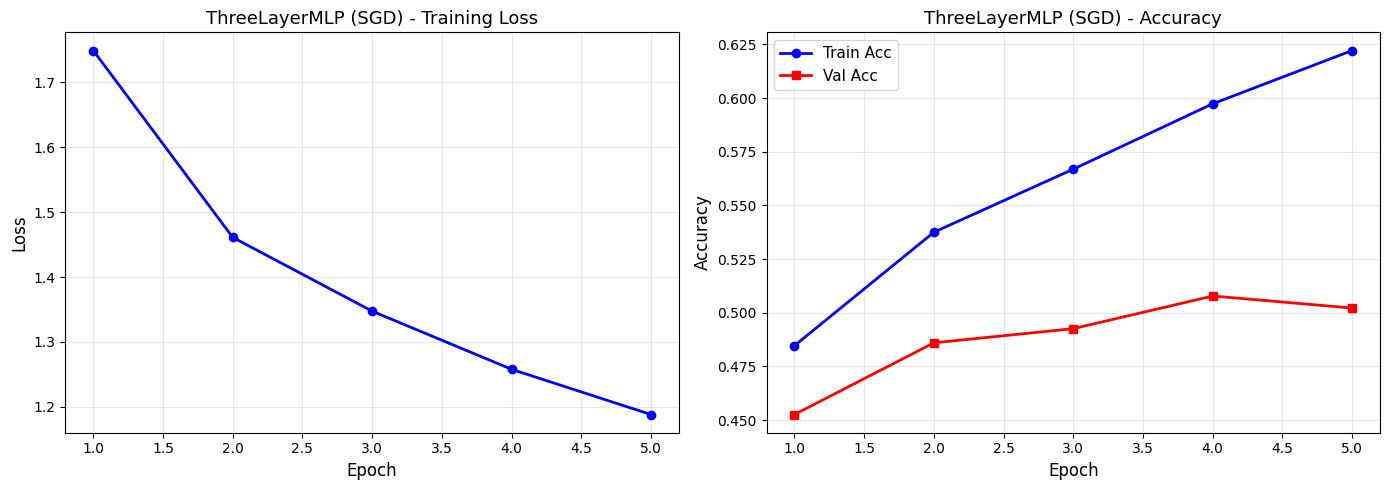

Final Train Acc: 0.6221
Final Val Acc:   0.5022


In [9]:
# 학습 과정 시각화: Loss + Accuracy 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history_3layer['train_loss']) + 1)

# Loss curve
axes[0].plot(epochs_range, history_3layer['train_loss'], 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('ThreeLayerMLP (SGD) - Training Loss', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_range, history_3layer['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=6)
axes[1].plot(epochs_range, history_3layer['val_acc'], 'r-s', label='Val Acc', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('ThreeLayerMLP (SGD) - Accuracy', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Acc: {history_3layer["train_acc"][-1]:.4f}')
print(f'Final Val Acc:   {history_3layer["val_acc"][-1]:.4f}')

Test Accuracy: 0.4951


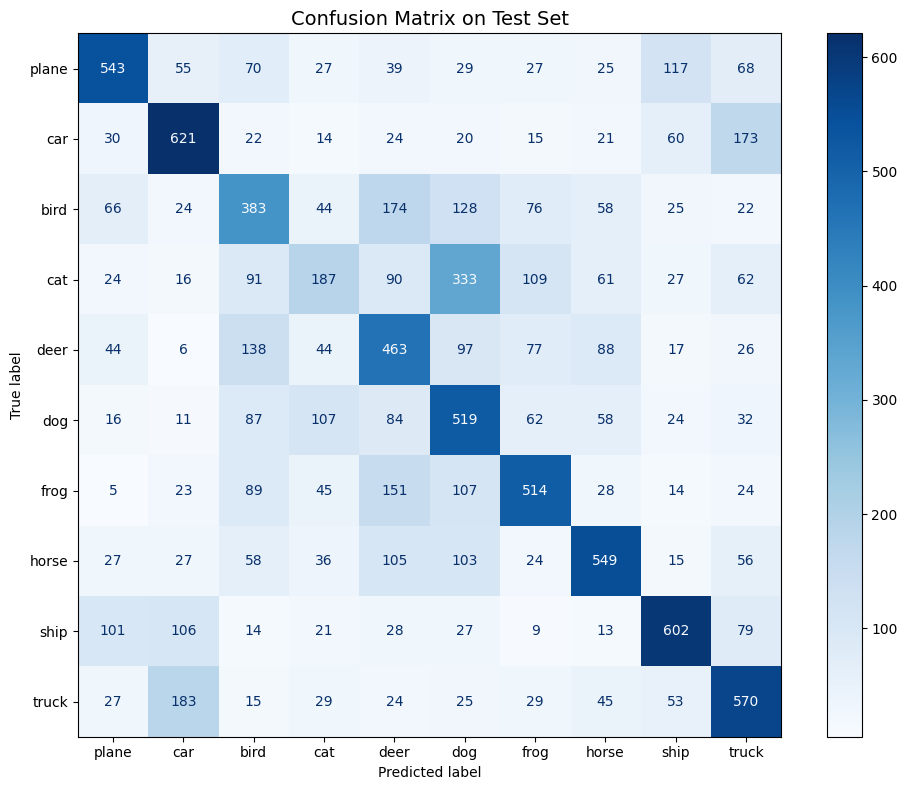

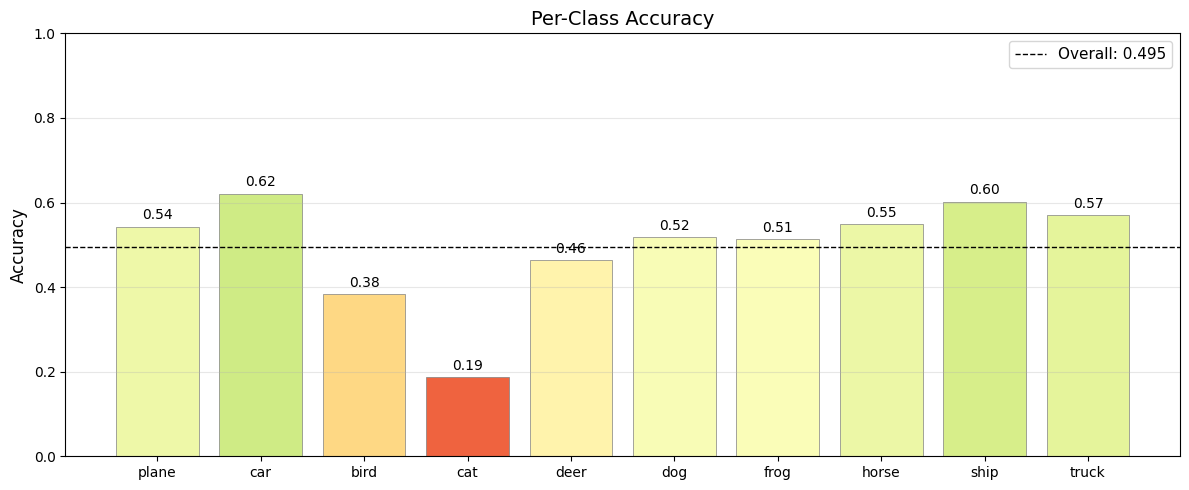

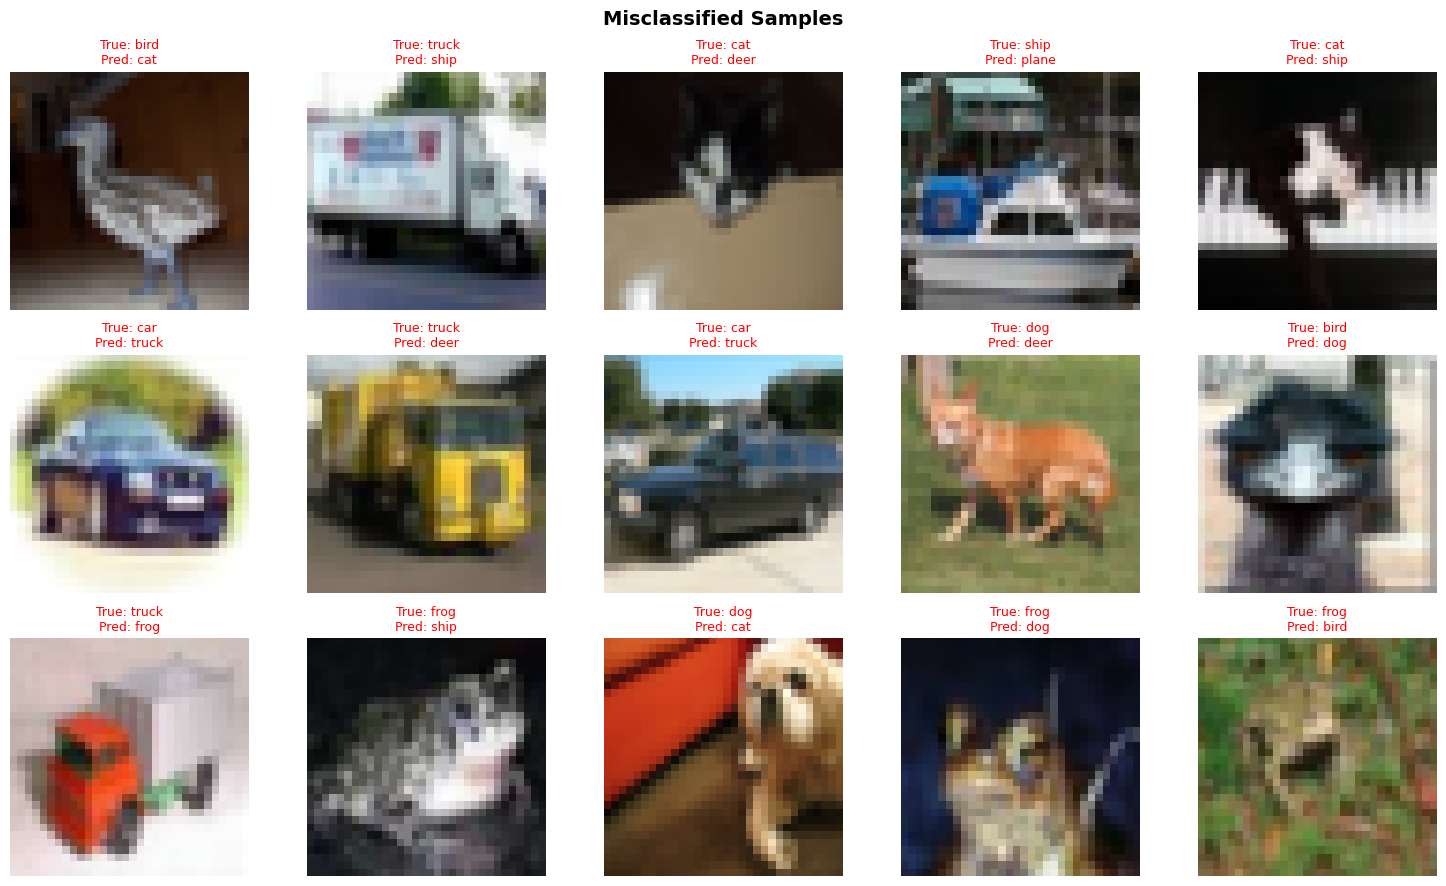

Total misclassified: 5049 / 10000 (50.5%)


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Confusion Matrix on Test Set ──
all_preds = []
all_labels = []
all_images = []

model_3layer.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model_3layer(images_dev)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_images.append(images)

all_images = torch.cat(all_images, dim=0)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f}')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

# ── Per-class Accuracy Bar Chart ──
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = plt.cm.RdYlGn(per_class_acc)  # 낮으면 빨강, 높으면 초록

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASSES, per_class_acc, color=colors, edgecolor='gray', linewidth=0.5)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy', fontsize=14)
ax.set_ylim(0, 1.0)
ax.axhline(y=test_acc, color='black', linestyle='--', linewidth=1, label=f'Overall: {test_acc:.3f}')
ax.legend(fontsize=11)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Misclassified Samples Visualization ──
misclassified_idx = np.where(all_preds != all_labels)[0]
np.random.seed(42)
sample_idx = np.random.choice(misclassified_idx, size=min(15, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, idx in enumerate(sample_idx):
    ax = axes[i // 5][i % 5]
    img = all_images[idx] * STD + MEAN  # 역정규화
    img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'True: {CLASSES[all_labels[idx]]}\nPred: {CLASSES[all_preds[idx]]}',
                 fontsize=9, color='red')
    ax.axis('off')
# 빈 subplot 제거
for i in range(len(sample_idx), 15):
    axes[i // 5][i % 5].axis('off')
plt.suptitle('Misclassified Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Total misclassified: {len(misclassified_idx)} / {len(all_labels)} ({len(misclassified_idx)/len(all_labels)*100:.1f}%)')

## 5. nn.Sequential API

`nn.Sequential`은 레이어를 순서대로 쌓는 간결한 방법입니다.
`forward()` 메서드를 직접 작성할 필요가 없습니다.

### nn.Sequential vs nn.Module 비교

| 항목 | `nn.Module` (직접 구현) | `nn.Sequential` |
|------|------------------------|-----------------|
| **유연성** | 높음 (skip connection, 분기 등 자유 구조) | 낮음 (순차적 구조만 가능) |
| **편의성** | 중간 (`forward()` 직접 작성) | 높음 (자동 연결) |
| **코드량** | 많음 (class + `__init__` + `forward`) | 적음 (한 줄~수 줄) |
| **사용 시점** | 복잡한 구조 (ResNet, U-Net, Attention) | 단순한 feed-forward, 프로토타이핑 |
| **디버깅** | 쉬움 (`forward`에서 중간값 확인 가능) | 어려움 (중간값 접근 불편) |

```python
# nn.Module 방식 (유연하지만 코드가 길다)
class MyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 256)
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x.flatten(1))))

# nn.Sequential 방식 (간결하다)
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3072, 256),
    nn.ReLU(),
    nn.Linear(256, 10),
)
```

> **가이드라인**: 단순한 실험이나 프로토타이핑에는 `nn.Sequential`,
> skip connection이나 multi-branch 구조가 필요하면 `nn.Module`을 사용하세요.

### TODO 3: 범용 MLP 빌더

hidden layer의 크기 리스트를 받아 자동으로 `nn.Sequential` 모델을 만드는 함수를 구현하세요.

예: `build_mlp([256, 128])` → `Flatten → Linear(3072,256) → ReLU → Linear(256,128) → ReLU → Linear(128,10)`


In [11]:
def build_mlp(hidden_dims, input_dim=3*32*32, num_classes=10):
    """
    hidden_dims 리스트를 받아 nn.Sequential MLP를 만드세요.

    Args:
        hidden_dims: hidden layer 크기 리스트 (e.g., [256, 128])
        input_dim: 입력 차원
        num_classes: 출력 클래스 수
    Returns:
        nn.Sequential 모델
    Hint: layers 리스트를 만들고, for문으로 Linear+ReLU를 추가한 뒤,
          마지막에 출력 Linear를 추가하고 nn.Sequential(*layers)로 반환하세요.
    """
    ############################################################################
    # TODO 3: build_mlp를 구현하세요 (~8줄)                                      #
    ############################################################################
    layers = [nn.Flatten()]
    in_dim = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(in_dim, h))
        layers.append(nn.ReLU())
        in_dim = h
    layers.append(nn.Linear(in_dim, num_classes))
    return nn.Sequential(*layers)
    #                             END OF YOUR CODE                             #
    ############################################################################

In [12]:
# build_mlp 검증
model_seq = build_mlp([256, 128])
dummy = torch.randn(4, 3, 32, 32)
out = model_seq(dummy)
print(f'Output shape: {out.shape}')  # [4, 10]

# nn.Module 버전과 파라미터 수 비교
params_module = sum(p.numel() for p in ThreeLayerMLP(3*32*32, 256, 128, 10).parameters())
params_seq = sum(p.numel() for p in model_seq.parameters())
print(f'ThreeLayerMLP (nn.Module) params: {params_module:,}')
print(f'build_mlp (nn.Sequential) params: {params_seq:,}')
print(f'Same architecture? {params_module == params_seq}')

# 모델 구조 출력
print(f'\nModel structure:')
print(model_seq)

# 다양한 구조 테스트
for dims in [[512], [256, 128], [512, 256, 128]]:
    m = build_mlp(dims)
    p = sum(p.numel() for p in m.parameters())
    print(f'build_mlp({dims}): {p:,} params')

Output shape: torch.Size([4, 10])
ThreeLayerMLP (nn.Module) params: 820,874
build_mlp (nn.Sequential) params: 820,874
Same architecture? True

Model structure:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)
build_mlp([512]): 1,578,506 params
build_mlp([256, 128]): 820,874 params
build_mlp([512, 256, 128]): 1,738,890 params


## 6. Residual Connection

깊은 네트워크에서는 입력에서 출력층까지의 경로가 길어질수록 gradient가 약해지는 경향이 자주 관찰됩니다.
**Residual connection** (skip connection) 은 한 블록의 입력을 그 블록의 출력에 더해주어,
gradient가 짧은 우회 경로(identity path)를 통해서도 흐를 수 있게 합니다.

수식으로 보면, 어떤 변환 $F$ 에 대해

$$y = F(x) + x$$

가 되며, 이 출력에 대한 입력의 미분은

$$\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I$$

로 항상 항등(identity) 항이 더해지기 때문에 깊은 stack에서도 0으로 사라지기 어려운 경향이 있습니다.
ResNet (He et al., 2015) 이후 이 구조는 깊은 네트워크 학습의 표준 구성요소로 자리 잡았습니다.

### TODO 4: ResidualBlock 구현
아래 `ResidualBlock.forward` 에서 두 Linear 변환(중간에 ReLU)을 거친 결과에 입력 `x` 를 그대로 더해 반환하세요.
입출력 차원이 같아야 더할 수 있으므로 이번 블록은 같은 `dim` 을 입력/출력으로 사용합니다.


In [13]:
class ResidualBlock(nn.Module):
    """
    하나의 residual block: [Linear -> ReLU -> Linear] + skip connection
    입력과 출력 차원이 같아야 skip이 그대로 더해질 수 있습니다.

    초기화 팁: 두 번째 Linear의 가중치를 작게 두면, 학습 초기에는 block이 거의
    identity에 가까워 깊게 쌓아도 신호가 안정적입니다 (Fixup 등 실제 ResNet
    변형에서 쓰이는 아이디어와 같은 맥락).
    """
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        # 두 번째 Linear을 작게 만들어 초기에는 residual contribution을 작게 둠
        with torch.no_grad():
            self.fc2.weight.mul_(0.1)
            self.fc2.bias.zero_()

    def forward(self, x):
        ############################################################################
        # TODO 4: residual forward를 구현하세요 (~3줄)                                  #
        # - out = F.relu(self.fc1(x))                                                  #
        # - out = self.fc2(out)                                                         #
        # - return out + x                                                              #
        ############################################################################
        out = F.relu(self.fc1(x))
        out = self.fc2(out)
        return out + x
        #                             END OF YOUR CODE                             #
        ############################################################################


# 비교용으로 skip이 없는 동일 구조 (Plain block) — kaiming init만 사용
class PlainBlock(nn.Module):
    """비교용 — skip이 없는 동일 구조.
    forward variance를 일부러 줄여 깊이가 깊어질수록 gradient가 사라지는 양상을 보이도록
    가중치를 kaiming의 절반 스케일로 초기화합니다 (vanishing 시나리오)."""
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        with torch.no_grad():
            self.fc1.weight.mul_(0.5)
            self.fc2.weight.mul_(0.5)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = self.fc2(out)
        return F.relu(out)


# Quick shape check
torch.manual_seed(0)
block = ResidualBlock(64)
dummy = torch.randn(8, 64)
print(f'input shape:  {tuple(dummy.shape)}')
print(f'output shape: {tuple(block(dummy).shape)}')
print(f'block params: {sum(p.numel() for p in block.parameters()):,}')
print(f'\nAt init, the residual block stays close to identity:')
print(f'  ||block(x) - x|| / ||x||  =  {((block(dummy) - dummy).norm() / dummy.norm()).item():.4e}')


input shape:  (8, 64)
output shape: (8, 64)
block params: 8,320

At init, the residual block stays close to identity:
  ||block(x) - x|| / ||x||  =  1.4194e-01


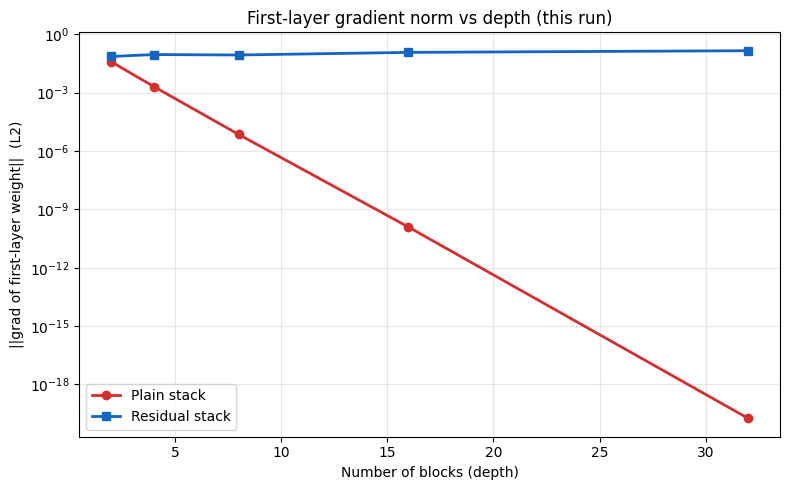


[ Observation (this run) ]
  depth=  2   plain: 3.842e-02    residual: 7.189e-02
  depth=  4   plain: 2.057e-03    residual: 9.026e-02
  depth=  8   plain: 7.075e-06    residual: 8.568e-02
  depth= 16   plain: 1.228e-10    residual: 1.168e-01
  depth= 32   plain: 1.814e-20    residual: 1.422e-01

-> at the same depth, the residual stack tends to keep a more stable first-layer gradient.
   The identity skip path means the gradient does not have to pass through every weight.


In [14]:
# Residual vs Plain: gradient flow at the first layer as depth grows
# Stack N blocks, do one forward + backward, measure ||grad of the very first weight||

def build_stack(block_class, n_blocks, dim=64):
    return nn.Sequential(*[block_class(dim) for _ in range(n_blocks)])


def first_layer_grad_norm(stack, dim=64, batch=16):
    x = torch.randn(batch, dim)
    target = torch.randn(batch, dim)
    out = stack(x)
    loss = ((out - target) ** 2).mean()
    stack.zero_grad()
    loss.backward()
    first_linear = stack[0].fc1   # the very first Linear in the deepest path
    return first_linear.weight.grad.norm().item()


depths = [2, 4, 8, 16, 32]
plain_norms = []
res_norms = []
for d in depths:
    torch.manual_seed(0)
    plain = build_stack(PlainBlock, d)
    plain_norms.append(first_layer_grad_norm(plain))

    torch.manual_seed(0)
    res = build_stack(ResidualBlock, d)
    res_norms.append(first_layer_grad_norm(res))


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, plain_norms, 'o-', color='#D32F2F', lw=2, label='Plain stack')
ax.plot(depths, res_norms, 's-', color='#1565C0', lw=2, label='Residual stack')
ax.set_xlabel('Number of blocks (depth)')
ax.set_ylabel('||grad of first-layer weight||  (L2)')
ax.set_yscale('log')
ax.set_title('First-layer gradient norm vs depth (this run)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('\n[ Observation (this run) ]')
for d, p, r in zip(depths, plain_norms, res_norms):
    print(f'  depth={d:3d}   plain: {p:.3e}    residual: {r:.3e}')
print('\n-> at the same depth, the residual stack tends to keep a more stable first-layer gradient.')
print('   The identity skip path means the gradient does not have to pass through every weight.')


## 7. train() vs eval() 모드

PyTorch에서 `model.train()`과 `model.eval()`은 특정 레이어의 **동작 모드**를 변경합니다.

| 레이어 | `model.train()` | `model.eval()` |
|--------|-----------------|----------------|
| **Dropout** | 확률 $p$로 뉴런을 랜덤 비활성화 | 모든 뉴런 활성화 (가중치 스케일링) |
| **BatchNorm** | 미니배치 통계 사용 + running stats 업데이트 | 저장된 running stats 사용 |
| **기타 레이어** (Linear, Conv 등) | 변화 없음 | 변화 없음 |

> **중요**: 추론(inference) 시에는 반드시 `model.eval()`을 호출하세요!
> 그렇지 않으면 Dropout이 뉴런을 끄고, BatchNorm이 불안정한 통계를 사용합니다.

아래에서 Dropout의 동작 차이를 확인합니다.


=== model.train() mode ===
  Run 1: output[0,:5] = [ 0.11   0.165  0.208 -0.047 -0.672]
  Run 2: output[0,:5] = [ 0.045  0.052  0.34  -0.076 -0.038]
  Run 3: output[0,:5] = [ 0.57   0.751 -0.058 -0.016 -0.443]
  Run 4: output[0,:5] = [ 0.32   0.532  0.383  0.114 -0.383]
  Run 5: output[0,:5] = [ 0.146  0.266 -0.211 -0.401 -0.617]
  -> Every run gives DIFFERENT output (dropout is stochastic)

=== model.eval() mode ===
  Run 1: output[0,:5] = [ 0.353  0.298  0.153 -0.258 -0.376]
  Run 2: output[0,:5] = [ 0.353  0.298  0.153 -0.258 -0.376]
  Run 3: output[0,:5] = [ 0.353  0.298  0.153 -0.258 -0.376]
  Run 4: output[0,:5] = [ 0.353  0.298  0.153 -0.258 -0.376]
  Run 5: output[0,:5] = [ 0.353  0.298  0.153 -0.258 -0.376]
  -> Every run gives THE SAME output (dropout is disabled)


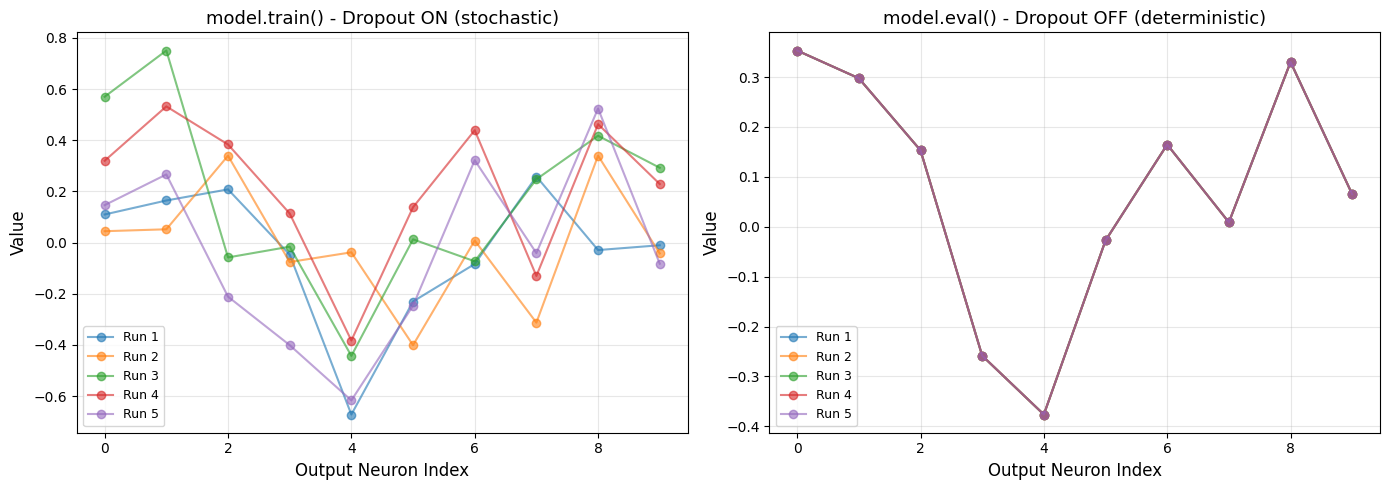

In [15]:
# train() vs eval() 모드에서 Dropout 동작 비교

class MLPWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3072, 256)
        self.dropout = nn.Dropout(p=0.5)  # 50% 확률로 뉴런 비활성화
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # train 모드에서만 동작
        x = self.fc2(x)
        return x

demo_model = MLPWithDropout()
demo_input = torch.randn(1, 3, 32, 32)

# === Train mode: Dropout 활성화 ===
demo_model.train()
print('=== model.train() mode ===')
outputs_train = []
for i in range(5):
    out = demo_model(demo_input)
    outputs_train.append(out)
    print(f'  Run {i+1}: output[0,:5] = {out[0,:5].detach().numpy().round(3)}')
print('  -> Every run gives DIFFERENT output (dropout is stochastic)')

print()

# === Eval mode: Dropout 비활성화 ===
demo_model.eval()
print('=== model.eval() mode ===')
outputs_eval = []
for i in range(5):
    out = demo_model(demo_input)
    outputs_eval.append(out)
    print(f'  Run {i+1}: output[0,:5] = {out[0,:5].detach().numpy().round(3)}')
print('  -> Every run gives THE SAME output (dropout is disabled)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train mode: 출력이 매번 다름
train_outputs = torch.stack(outputs_train).squeeze().detach().numpy()
for i in range(5):
    axes[0].plot(range(10), train_outputs[i], 'o-', alpha=0.6, label=f'Run {i+1}')
axes[0].set_xlabel('Output Neuron Index', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('model.train() - Dropout ON (stochastic)', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Eval mode: 출력이 항상 같음
eval_outputs = torch.stack(outputs_eval).squeeze().detach().numpy()
for i in range(5):
    axes[1].plot(range(10), eval_outputs[i], 'o-', alpha=0.6, label=f'Run {i+1}')
axes[1].set_xlabel('Output Neuron Index', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('model.eval() - Dropout OFF (deterministic)', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 정리 및 실용 팁


### 실용 팁: 알아두면 좋은 것들

#### `torchsummary`로 모델 구조 확인하기
```python
# pip install torchsummary
from torchsummary import summary
summary(model, input_size=(3, 32, 32))
# → 레이어별 출력 크기, 파라미터 수를 깔끔하게 표시
```

#### `model.train()` / `model.eval()` 체크리스트
```python
# 학습 시
model.train()
for x, y in train_loader:
    loss = ...
    loss.backward()
    optimizer.step()

# 평가/추론 시
model.eval()
with torch.no_grad():        # gradient 계산 비활성화 → 메모리 절약
    for x, y in val_loader:
        outputs = model(x)
```

#### `torch.no_grad()` vs `torch.inference_mode()`
```python
# torch.no_grad(): gradient 계산 비활성화 (평가 시 사용)
with torch.no_grad():
    outputs = model(x)

# torch.inference_mode(): 더 강력한 최적화 (PyTorch 1.9+)
# 실제 추론에서는 이쪽이 더 빠름
with torch.inference_mode():
    outputs = model(x)
```

#### 자주 하는 실수
- `model.eval()` 호출 안 하고 평가 → Dropout이 뉴런을 꺼서 성능 하락
- `optimizer.zero_grad()` 빠뜨림 → gradient 누적으로 학습 불안정
- `loss.backward()` 전에 `detach()` 호출 → gradient 흐름 끊김
